In [22]:
import os
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore', message='use_inf_as_na option is deprecated')
pd.set_option("display.max_rows", None)  # Show all rows
pd.set_option("display.max_columns", None)  # Show all columns (optional)


# Processing

In [15]:
pwd

'/Users/avshah/P_llm_auctions/llm-auction/analysis'

In [23]:
import pandas as pd
import os

# Define the directory paths
basic_path = '/Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/'
closing_dir_path = basic_path + "ebay_closing_rule"
closing_and_reserve_dir_path = basic_path + "ebay_closing_rule_with_hidden_reserve_40"
basic_proxy_dir_path = basic_path + "ebay_proxy"
reserve_dir_path = basic_path + "ebay_proxy_with_hidden_reserve_40"

# --- Closing Rule ---
closing_csv_files = [f for f in os.listdir(closing_dir_path) if f.endswith(".csv")]
closing_dfs = []
for i, file in enumerate(closing_csv_files):
    df = pd.read_csv(os.path.join(closing_dir_path, file))
    df['exp_num'] = i
    closing_dfs.append(df)
closing_df = pd.concat(closing_dfs, ignore_index=True)

# --- Closing Rule with Hidden Reserve ---
closing_and_reserve_csv_files = [f for f in os.listdir(closing_and_reserve_dir_path) if f.endswith(".csv")]
closing_and_reserve_dfs = []
for i, file in enumerate(closing_and_reserve_csv_files):
    df = pd.read_csv(os.path.join(closing_and_reserve_dir_path, file))
    df['exp_num'] = i
    closing_and_reserve_dfs.append(df)
closing_and_reserve_df = pd.concat(closing_and_reserve_dfs, ignore_index=True)

# --- Basic Proxy ---
basic_proxy_csv_files = [f for f in os.listdir(basic_proxy_dir_path) if f.endswith(".csv")]
basic_proxy_dfs = []
for i, file in enumerate(basic_proxy_csv_files):
    df = pd.read_csv(os.path.join(basic_proxy_dir_path, file))
    df['exp_num'] = i
    basic_proxy_dfs.append(df)
basic_proxy_df = pd.concat(basic_proxy_dfs, ignore_index=True)

# --- Reserve ---
reserve_csv_files = [f for f in os.listdir(reserve_dir_path) if f.endswith(".csv")]
reserve_dfs = []
for i, file in enumerate(reserve_csv_files):
    df = pd.read_csv(os.path.join(reserve_dir_path, file))
    df['exp_num'] = i
    reserve_dfs.append(df)
reserve_df = pd.concat(reserve_dfs, ignore_index=True)

# Optionally, print the shapes of the resulting DataFrames
print("Shape of closing_df:", closing_df.shape)
print("Shape of closing_and_reserve_df:", closing_and_reserve_df.shape)
print("Shape of basic_proxy_df:", basic_proxy_df.shape)
print("Shape of reserve_df:", reserve_df.shape)

# # Optionally, save the merged DataFrames to CSV files
# closing_df.to_csv("closing_df.csv", index=False)
# closing_and_reserve_df.to_csv("closing_and_reserve_df.csv", index=False)
# basic_proxy_df.to_csv("basic_proxy_df.csv", index=False)
# reserve_df.to_csv("reserve_df.csv", index=False)

Shape of closing_df: (1008, 11)
Shape of closing_and_reserve_df: (1017, 11)
Shape of basic_proxy_df: (900, 11)
Shape of reserve_df: (900, 11)


# Plotting

In [24]:
def process_dataframe(df):
    """
    Processes the DataFrame to add 'normalized_price' column.

    Args:
        df: pandas DataFrame with auction data (including 'period_id', 'turn_id',
            'current_price', 'action', 'exp_num' columns).

    Returns:
        pandas DataFrame with added 'normalized_price' column.
    """

    # Reset the index to ensure 'period_id' is a column
    df = df.reset_index(drop=True)

    # Calculate normalized price within each experiment
    def calculate_normalized_price(group):
        final_price = group['current_price'].iloc[-1]
        group['normalized_price'] = group['current_price'] / final_price if final_price != 0 else 0
        return group

    df = df.groupby('exp_num').apply(calculate_normalized_price) #Group by experiment now
    return df

def plot_avg_price(df, label=""):
    """
    Plot current price by time. 

    Input: df, string label.
    Output: plot
    """
    plt.figure(figsize=(10,6))

    sns.lineplot(data = df, x = 'period_id', y = 'current_price')

    plt.xlabel("Period ID")
    plt.ylabel("Current Price")
    plt.title(f"Current Price vs. Period ID ({label})")
    plt.legend()  # Show the legend including "Average"
    plt.show()

def plot_price_vs_time(df, label=""):
    """
    Plots the normalized price against the period ID, with an average line.

    Args:
        df: pandas DataFrame with 'period_id', 'normalized_price', 'exp_num' columns.
    """
    plt.figure(figsize=(10, 6))

    # Plot individual experiment lines with reduced alpha (transparency)
    sns.lineplot(data=df, x='period_id', y='normalized_price', hue='exp_num', legend="full", alpha=0.5, errorbar=None, palette="viridis")  # Reduced alpha

    # Plot the average line with standard deviation shading using seaborn
    sns.lineplot(data=df, x='period_id', y='normalized_price', estimator='mean', errorbar='sd', color='black', linewidth=3, label='Average')

    plt.xlabel("Period ID")
    plt.ylabel("Current Price / Final Experiment Price")
    plt.title(f"Normalized Price vs. Period ID ({label})")
    plt.legend()  # Show the legend including "Average"
    plt.show()

def plot_last_bid_histogram(df, label = ""):
    """
    Plots a histogram of the period ID in which the last bid was placed for each experiment.

    Args:
        df: pandas DataFrame with 'period_id', 'action', and 'exp_num' columns.
    """

    plt.figure(figsize=(10, 6))
    experiment_ids = df['exp_num'].unique()
    last_bid_period_list = []

    for exp_num in experiment_ids:
        experiment_data = df[df['exp_num'] == exp_num]

        # Find the *last* period where a 'bid' action occurred
        last_bid_period_list.append(experiment_data[experiment_data['action'] == 'bid']['period_id'].max())

    # Plot histogram if possible.
    sns.histplot(last_bid_period_list, alpha=0.5, label=f"Experiment {exp_num}", binwidth=1)

    print("The final bid day is: ", last_bid_period_list)
    plt.xlabel("Period ID of Last Bid")
    plt.ylabel("Counts")
    plt.ylim(top = 10)
    plt.title(f"Histogram of Last Bid Time ({label})")
    plt.legend()
    plt.show()

# Proxy plots

/var/folders/qx/p3d0v1413yn2121qcx6nmklw0000gq/T/ipykernel_60899/3024379124.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()  # Show the legend including "Average"


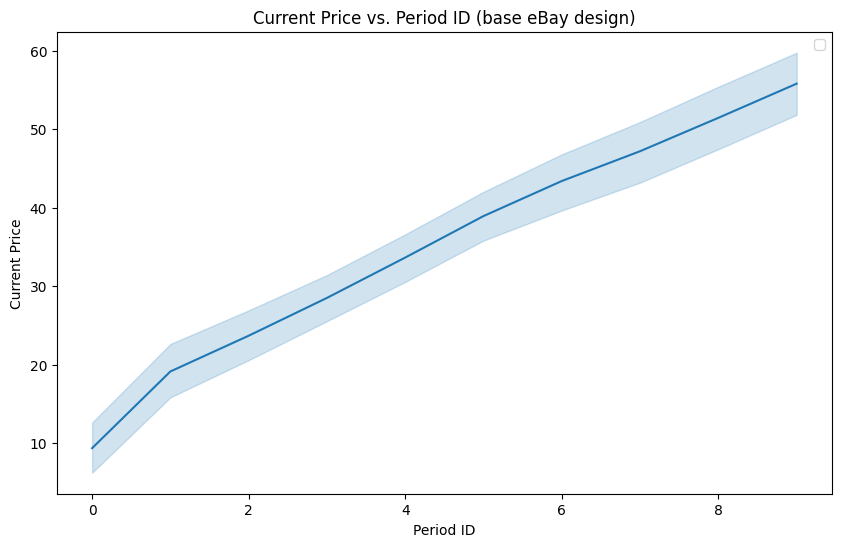

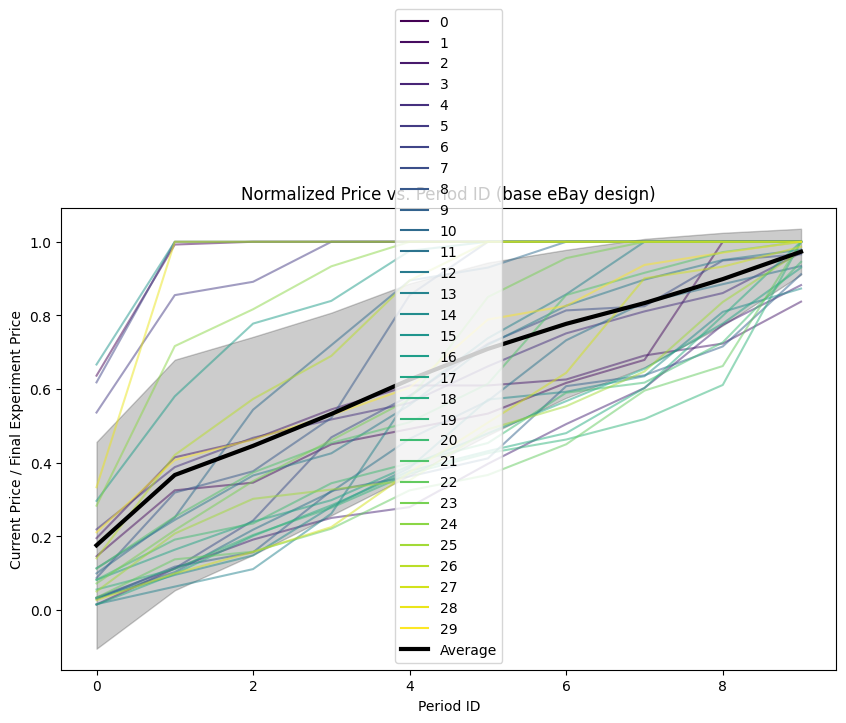

The final bid day is:  [6, 9, 9, 9, 9, 3, 1, 9, 4, 9, 9, 9, 9, 7, 9, 0, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 5, 9, 6, 9]


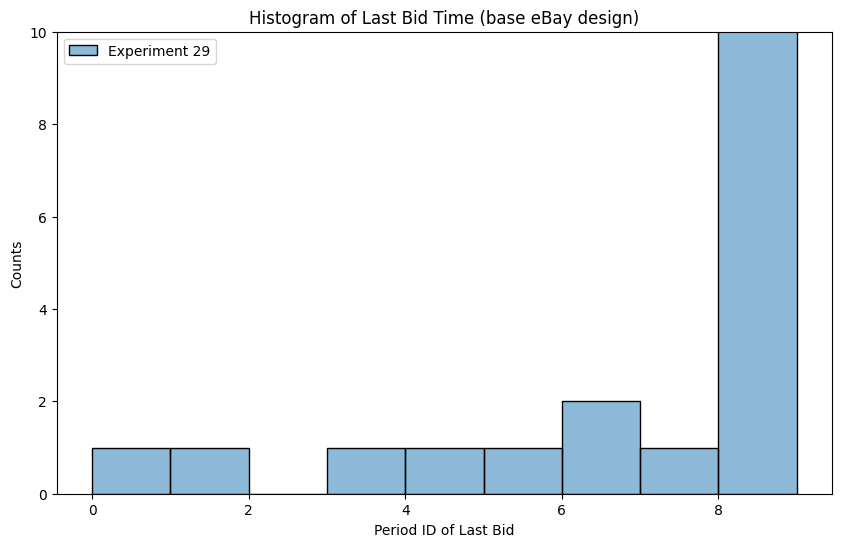

In [25]:
df = process_dataframe(basic_proxy_df)
plot_avg_price(df, label="base eBay design")
plot_price_vs_time(df, label="base eBay design")
plot_last_bid_histogram(df, label="base eBay design")

# Closing rule plots

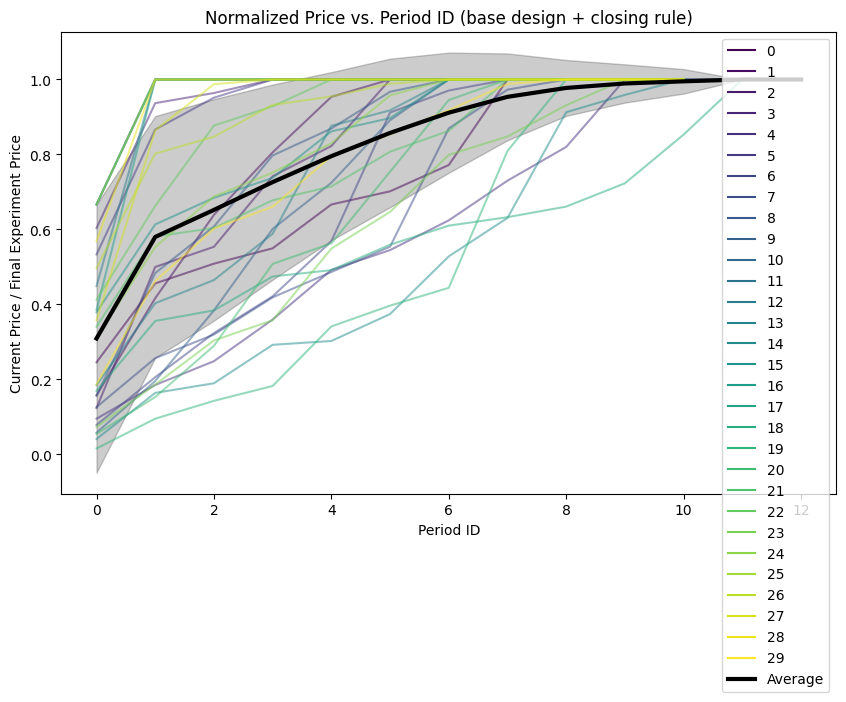

The final bid day is:  [7, 9, 5, 6, 8, 5, 10, 8, 7, 6, 4, 0, 5, 5, 9, 6, 0, 0, 10, 8, 6, 7, 5, 8, 7, 0, 5, 8, 0, 7]


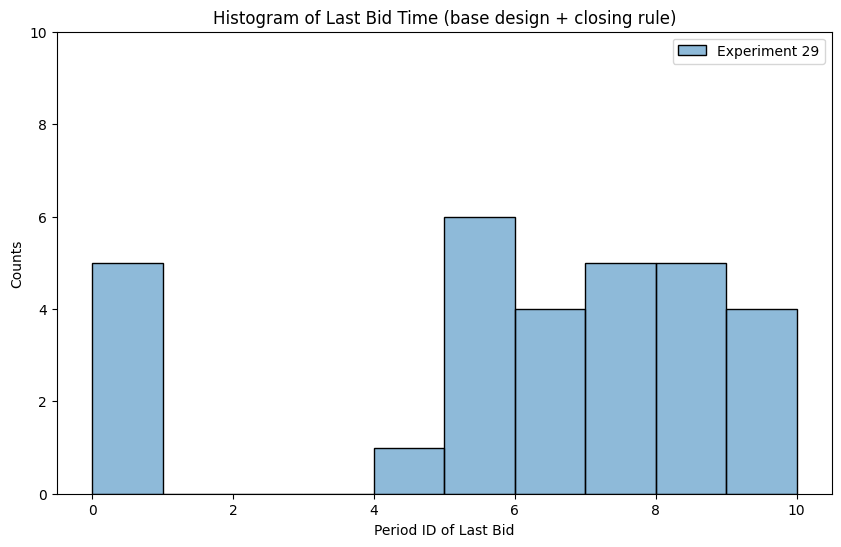

In [19]:
df = process_dataframe(closing_df)
plot_price_vs_time(df, label="base design + closing rule")
plot_last_bid_histogram(df, label = "base design + closing rule")

# Hidden reserve plots

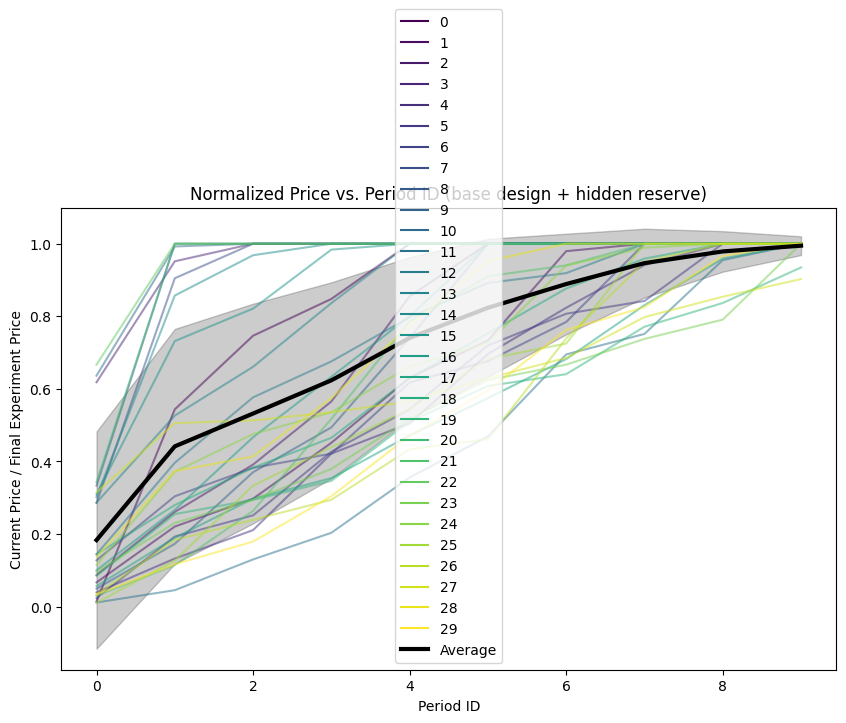

The final bid day is:  [4, 8, 8, 1, 9, 9, 9, 1, 4, 6, 9, 9, 7, 4, 2, 7, 9, 9, 9, 9, 1, 9, 3, 9, 9, 7, 9, 9, 7, 8]


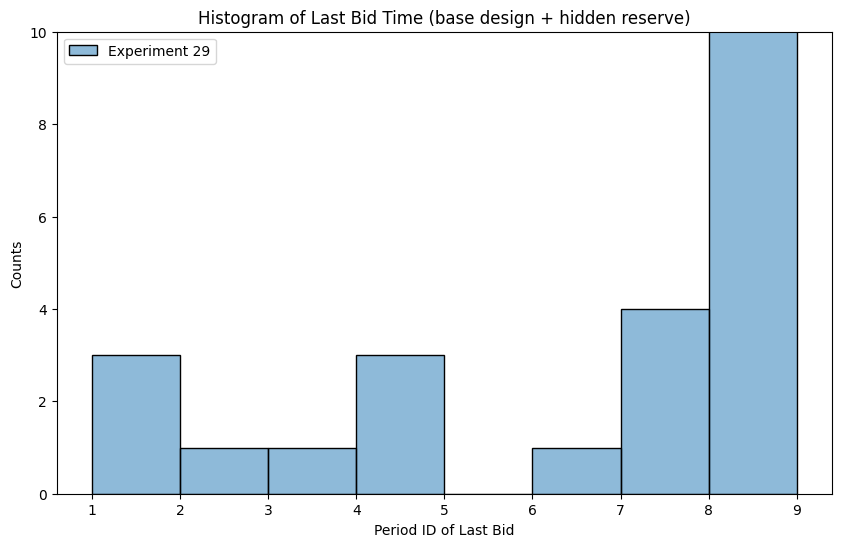

In [20]:
df = process_dataframe(reserve_df)
plot_price_vs_time(df, label="base design + hidden reserve")
plot_last_bid_histogram(df, label="base design + hidden reserve")

# Closing + Hidden reserve plots

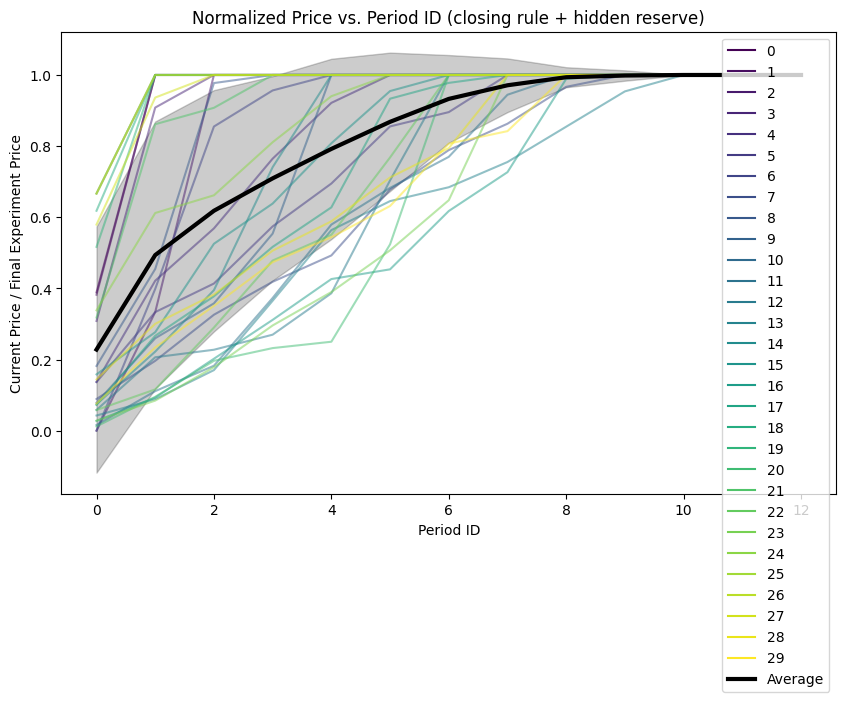

The final bid day is:  [0, 0, 7, 4, 10, 7, 3, 8, 7, 4, 1, 9, 6, 9, 8, 5, 10, 10, 1, 8, 8, 5, 6, 10, 9, 0, 1, 2, 7, 8]


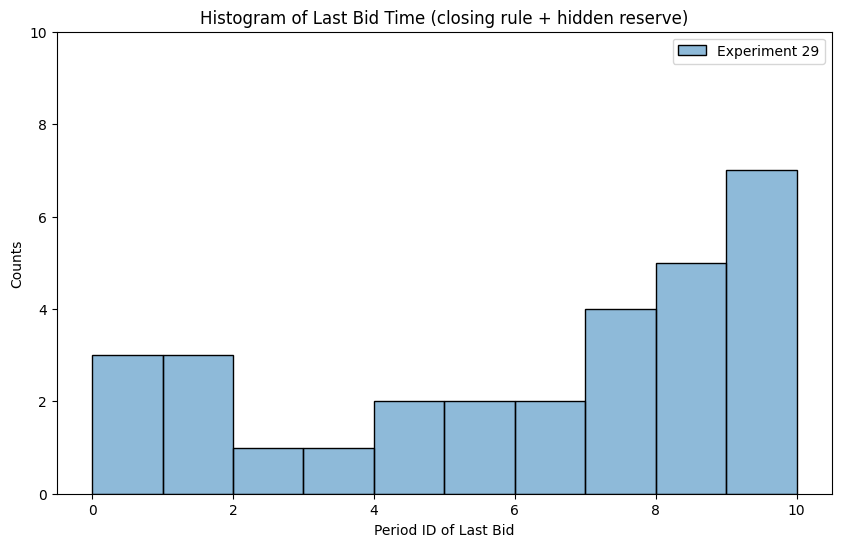

In [21]:
df = process_dataframe(closing_and_reserve_df)
plot_price_vs_time(df, label="closing rule + hidden reserve")
plot_last_bid_histogram(df, label="closing rule + hidden reserve")

# Summary plots

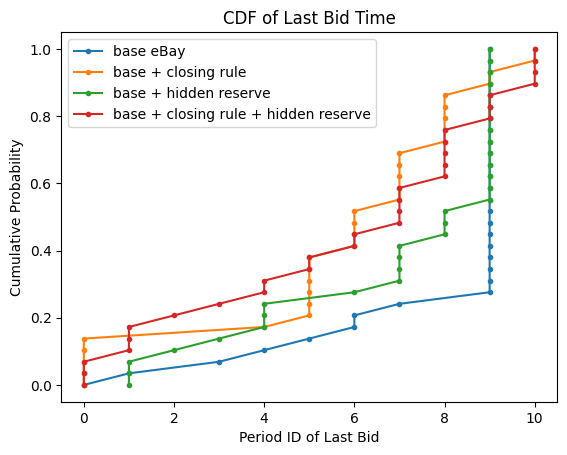

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cdf_from_list(data_list, label=""):
    """
    Plots a CDF from a given list of values.

    Args:
        data_list (list): A list of numerical values.
        label (str): A label for the CDF (for the legend).
    """
    # Sort the data
    sorted_data = np.sort(data_list)
    # Create cumulative probabilities
    p = np.arange(len(sorted_data)) / (len(sorted_data) - 1)

    # Plot the CDF
    plt.plot(sorted_data, p, marker='.', linestyle='-', label=label)

# Example with multiple lists
last_bid_periods_1 = [6, 9, 9, 9, 9, 3, 1, 9, 4, 9, 9, 9, 9, 7, 9, 0, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 5, 9, 6, 9]
last_bid_periods_2 = [7, 9, 5, 6, 8, 5, 10, 8, 7, 6, 4, 0, 5, 5, 9, 6, 0, 0, 10, 8, 6, 7, 5, 8, 7, 0, 5, 8, 0, 7]
last_bid_periods_3 = [4, 8, 8, 1, 9, 9, 9, 1, 4, 6, 9, 9, 7, 4, 2, 7, 9, 9, 9, 9, 1, 9, 3, 9, 9, 7, 9, 9, 7, 8]
last_bid_periods_4 = [0, 0, 7, 4, 10, 7, 3, 8, 7, 4, 1, 9, 6, 9, 8, 5, 10, 10, 1, 8, 8, 5, 6, 10, 9, 0, 1, 2, 7, 8]

#Create multiple lists.
all_last_bids = [last_bid_periods_1, last_bid_periods_2, last_bid_periods_3, last_bid_periods_4]

#Create labels
labels = ["base eBay", "base + closing rule", "base + hidden reserve", "base + closing rule + hidden reserve"]

#Set all plots to the figure object.
plt.figure()

#Iterate through multiple times and label for each experiment.
for bid, label in zip(all_last_bids, labels):
    plot_cdf_from_list(bid, label=label)

#Make plot prettier.
plt.xlabel("Period ID of Last Bid")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Last Bid Time")
plt.grid(False)
plt.legend()
plt.show()

In [11]:
basic_proxy_df['exp_type'] = "base eBay"
closing_df['exp_type'] = "base eBay + closing"
reserve_df['exp_type'] = "base eBay + hidden reserve"
closing_and_reserve_df['exp_type'] = "base eBay + closing + hidden reserve"
df = pd.concat([basic_proxy_df, closing_df, reserve_df, closing_and_reserve_df], ignore_index=True)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_avg_price(df, label=""):
    """
    Plot current price by time.

    Input: df, string label.
    Output: plot
    """
    plt.figure(figsize=(10, 6))

    # Plot the average current price for each period ID
    sns.lineplot(data=df, x='period_id', y='current_price', hue='exp_type')  # Show lines by experiment

    plt.xlabel("Period ID")
    plt.ylabel("Current Price")
    plt.title(f"Current Price vs. Period ID ({label})")
    plt.legend(title='Experiment')  # Add a legend and better title
    plt.show()

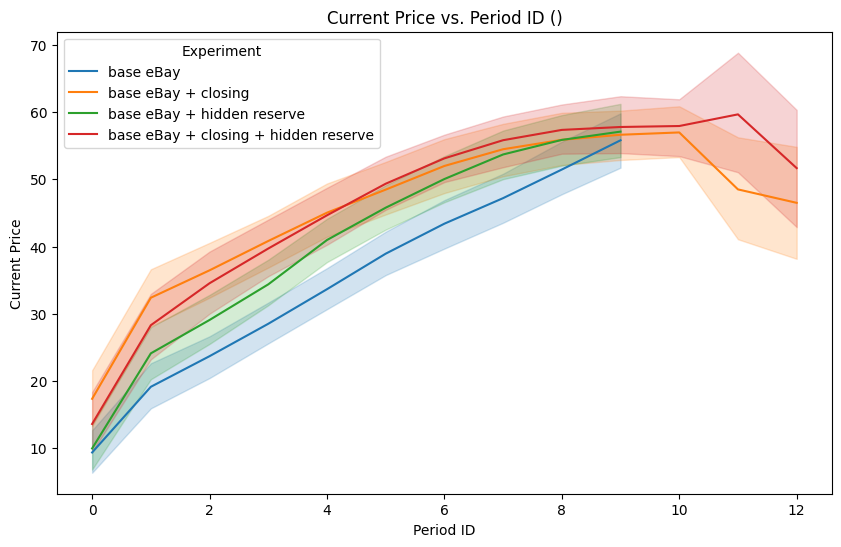

In [12]:
plot_avg_price(df, label="")

In [13]:
df

,period_id,turn_id,current_price,reserve_price,agent_selected,action,bid,max_bids,highest_bidder,exp_num,value,exp_type
0,0,0,0.0,0,Bidder Betty,bid,40.0,"{'Bidder Andy': 0, 'Bidder Betty': 40.0, 'Bidd...",Bidder Betty,0,NaN,base eBay
1,0,1,41.0,0,Bidder Andy,bid,43.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Andy,0,NaN,base eBay
2,0,2,43.0,0,Bidder Charles,bid,42.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Andy,0,NaN,base eBay
3,1,0,43.0,0,Bidder Betty,hold,0.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Andy,0,NaN,base eBay
4,1,1,44.0,0,Bidder Charles,bid,45.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Charles,0,NaN,base eBay
5,1,2,44.0,0,Bidder Andy,hold,0.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Charles,0,NaN,base eBay
6,2,0,44.0,0,Bidder Charles,bid,50.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Charles,0,NaN,base eBay
7,2,1,44.0,0,Bidder Andy,hold,0.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Charles,0,NaN,base eBay
8,2,2,44.0,0,Bidder Betty,hold,0.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Charles,0,NaN,base eBay
9,3,0,44.0,0,Bidder Betty,hold,0.0,"{'Bidder Andy': 43.0, 'Bidder Betty': 40.0, 'B...",Bidder Charles,0,NaN,base eBay
